<a href="https://colab.research.google.com/github/dragoa/MachineLearning/blob/main/DeepLearning%20AI/%5BSPZ%5D%20PyTorch%20for%20Deep%20Learning/Module%204/CNN_for_Nature_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a CNN for Nature Classification

In this notebook we are gonna build a CNN that can classify not just flowers, but also insects and small animals.
Linear layers you won’t be enough to capture the rich visual patterns in these diverse images. To meet this new challenge, we’ll build a **Convolutional Neural Network (CNN)**, a model designed to recognize shapes, textures, and features in visual data.

We’ll not only implement the architecture but also follow an iterative workflow—starting with a smaller prototype before scaling up—and learn how to diagnose common training issues.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from collections import defaultdict

import os
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Preparing the Nature Dataset

We'll work with a collection of images taken from the well-known [CIFAR-100 dataset](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR100.html). This dataset contains thousands of small, **32x32 color images** that are perfect for training a CNN.

While CIFAR-100 has 100 different classes, we'll focus on a subset of **15 classes** that fit the theme of a nature classifier.

* **Flowers**: 'orchid', 'poppy', 'rose', 'sunflower', 'tulip'

* **Mammals**: 'fox', 'porcupine', 'possum', 'raccoon', 'skunk'

* **Insects**: 'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'

### Image Transformations

Before loading the dataset, we need to define the transformation pipelines for it. Since all images in the dataset are already a standard **32x32** size, we don't need to add a resizing step. Your training pipeline will include data augmentation, while both pipelines will convert images to **tensors** and **normalize** them using the standard mean and standard deviation for the CIFAR-100 dataset.

In [3]:
cifar100_mean = (0.5071, 0.4867, 0.4408)
cifar100_std = (0.2675, 0.2565, 0.2761)

In [4]:
# training trasformation pipeline
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.20),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar100_mean, std=cifar100_std)
])

# test trasformation pipeline
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar100_mean, std=cifar100_std)
])

### Load the data

We gonna load the full CIFAR-100 dataset and at first consider a subset of just 9 classes to then scale up

In [5]:
subset_target_classes = [
  # Flowers
  'orchid', 'poppy', 'sunflower',
  # Mammals
  'fox', 'raccoon', 'skunk',
  # Insects
  'butterfly', 'caterpillar', 'cockroach'
]

In [6]:
def _filter_dataset(dataset, target_indices, label_map, target_classes):
  """
  Function to filter samples of the dataset following the target_classes variable
  """
  # Convert the list of targets to a NumPy array for efficient boolean indexing
  targets_np = np.array(dataset.targets)
  # Create a boolean mask to identify which samples belong to the target classes
  indices_to_keep = np.isin(targets_np, target_indices)

  # Filter the dataset's image data using the boolean mask
  dataset.data = dataset.data[indices_to_keep]

  # Get the original labels of the samples that are being kept
  original_targets_to_keep = targets_np[indices_to_keep]
  # Remap the original labels to the new contiguous labels
  dataset.targets = [label_map[target] for target in original_targets_to_keep]

  # Update the dataset's class list to only include the target classes
  dataset.classes = target_classes
  return dataset


def load_cifar100_subset(target_classes, train_transform, test_transform, root="/content/cifar_100/"):
  """
  Function to download the full cifar100 dataset and the return the filtered subset
  """

  cifar100_path = os.path.join(root, "cifar-100-python")
  if os.path.exists(cifar100_path):
    print("Dataset already downloaded, skipping...")
  else:
    print("Dataset not found, downloading...")

  train_dataset_full = torchvision.datasets.CIFAR100(
      root=root,
      train=True,
      download=True,
      transform=train_transform
  )

  test_dataset_full = torchvision.datasets.CIFAR100(
      root=root,
      train=False,
      download=True,
      transform=test_transform
  )

  print("Dataset downloaded succesfully!")

  # Get the list of all class names from the dataset.
  all_classes = train_dataset_full.classes
  try:
    # Filter only the indices of the classes that we want
    target_indices = [all_classes.index(cls) for cls in target_classes]
  # Handle the case where a specified class name is not in the dataset
  except ValueError as e:
    print(f"Error: One of the target classes not found in CIFAR-100. {e}")
    return None, None

  # Create new mapping with contiguous indices (0, 1, 2, ...)
  label_map = {old_label: new_label for new_label, old_label in enumerate(target_indices)}

  # Filter Train Dataset
  train_dataset_filtered = _filter_dataset(train_dataset_full, target_indices, label_map, target_classes)
  # Filter Test Dataset
  test_dataset_filtered = _filter_dataset(test_dataset_full, target_indices, label_map, target_classes)

  return train_dataset_filtered, test_dataset_filtered

In [7]:
train_dataset_proto, val_dataset_proto = load_cifar100_subset(subset_target_classes, train_transform, test_transform)

Dataset already downloaded, skipping...
Dataset downloaded succesfully!


In [8]:
# Now is the time to create the DataLoaders
batch_size = 64

train_loader_proto = DataLoader(train_dataset_proto, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader_proto = DataLoader(val_dataset_proto, batch_size=batch_size, shuffle=False, num_workers=2)

In [9]:
print("--Train--")
print(train_loader_proto.dataset)
print("--Test--")
print(val_loader_proto.dataset)

--Train--
Dataset CIFAR100
    Number of datapoints: 4500
    Root location: /content/cifar_100/
    Split: Train
    StandardTransform
Transform: Compose(
               RandomHorizontalFlip(p=0.5)
               RandomVerticalFlip(p=0.2)
               RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
           )
--Test--
Dataset CIFAR100
    Number of datapoints: 900
    Root location: /content/cifar_100/
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
           )


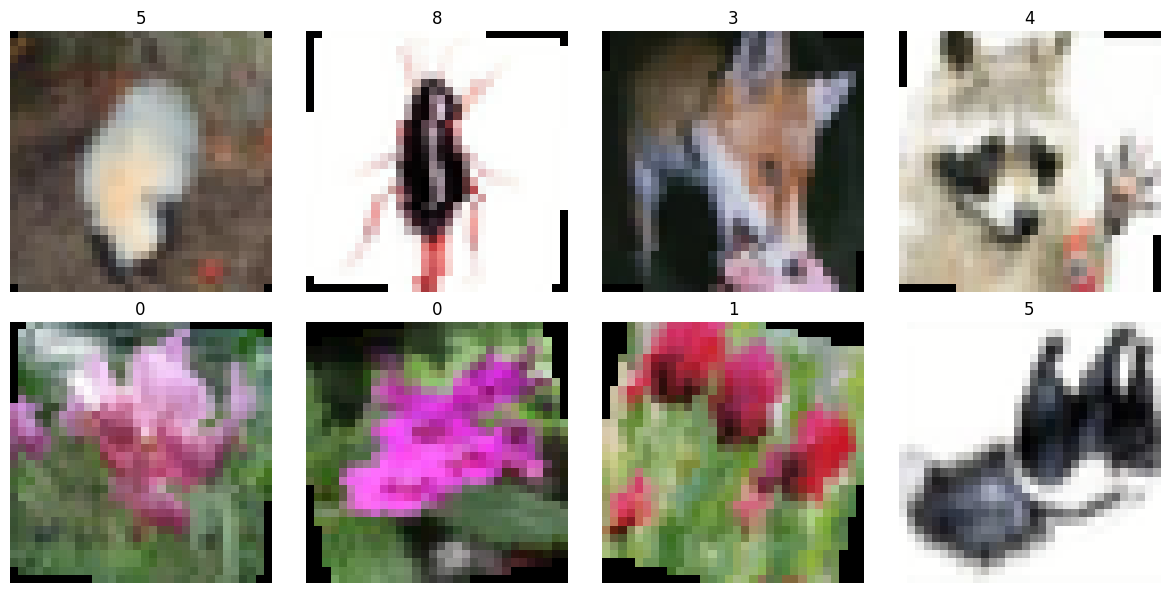

In [10]:
def denormalize_image(tensor, mean, std):
  # compute the new mean for denormalize
  new_mean = [-m/s for m,s in zip(mean, std)]
  new_std = [1/s for s in std]

  denormalize = transforms.Normalize(mean=new_mean, std=new_std)

  return denormalize(tensor)


# visualize images
def visualize_images(dataset, n_rows, n_cols):
  total = n_rows * n_cols
  indicies = np.random.choice(len(dataset), total, replace=False)

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))

  axes = axes.ravel()

  for ax, idx in zip(axes, indicies):
    image, label = dataset[idx]

    image = denormalize_image(image, cifar100_mean, cifar100_std)
    # transpose (C, H, W) to (H, W, C) for visualization
    image = image.numpy().transpose((1, 2, 0))

    ax.imshow(image)
    ax.set_title(f"{label}")
    ax.axis("off")

  plt.tight_layout()
  plt.show()

visualize_images(train_dataset_proto, 2, 4)

## Building the CNN Architecture
**Convolutional Layer (<code>[nn.Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)</code>)**
> This is the core building block of a CNN, using learnable filters to scan the image for visual features. The output is a set of "feature maps" that highlight where in the image these patterns appear.
> * `in_channels`: The number of channels from the previous layer; for the first layer, this is 3 for the RGB color channels.
> * `out_channels`: The number of filters the layer will learn, determining the number of output feature maps.
> * `kernel_size`: The dimensions of the filter, such as a 3x3 grid that examines a pixel and its immediate neighbors.
> * `padding`: Adds a border around the image, allowing the kernel to process edge pixels while preserving the image's dimensions.

**ReLU Activation Function (<code>[nn.ReLU](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)</code>)**
> An activation function that introduces non-linearity by changing all negative values in the feature maps to zero. This helps the model learn more complex patterns.

**Max Pooling Layer (<code>[nn.MaxPool2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)</code>)**
> This layer downsamples the feature maps by reducing their height and width, which makes the network more efficient. It slides a window over the feature map and keeps only the single largest value from that window, discarding the rest.
> * `kernel_size`: The size of the window to perform pooling on, such as a 2x2 area.
> * `stride`: The step size the window moves across the image. A stride of 2 with a 2x2 kernel will halve the feature map's dimensions.

**Flatten Layer (<code>[nn.Flatten](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html)</code>)**
> A utility layer that unrolls the 2D feature maps into a single 1D vector. This is a necessary step to prepare the data for the fully connected linear layers.

**Linear Layer (<code>[nn.Linear](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)</code>)**
> Also known as a fully connected layer, it performs the final classification. It combines the features learned by the convolutional layers into a final prediction.

**Dropout Layer (<code>[nn.Dropout](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html)</code>)**
> A regularization technique that helps prevent overfitting by randomly setting a fraction of neuron activations to zero during training. This forces the network to learn more robust features instead of relying too heavily on any single pattern.

In [11]:
class SimpleCNN(nn.Module):
  """
  Simple CNN model. Consist of 3 convolutional blocks and 2 fully
  connected layers for classification
  """
  def __init__(self, num_classes):
    """
    Initialize the layers of the neural network
    """
    # Calls the constructor of the parent class
    super().__init__()

    # Define the first convolutional block
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
    self.relu1 = nn.ReLU()
    # (32, 32, 32) -> (32, 16, 16)
    self.max_pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    # Define the second convolutional block
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
    self.relu2 = nn.ReLU()
    # (64, 16, 16) -> (64, 8, 8)
    self.max_pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    # Define the third convolutional block
    self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
    self.relu3 = nn.ReLU()
    # (128, 8, 8) -> (128, 4, 4)
    self.max_pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

    # Flatten
    self.flatten = nn.Flatten()

    # Define first fully connected layer
    # 128 out channels, 4*4 feature map after the pooling ->
    # out = ⌊(W + 2P - K)/ S⌋ + 1, W:width/height | P:padding | K:kernel size | S:stride
    self.fc1 = nn.Linear(128*4*4, 512)
    self.relu4 = nn.ReLU()
    # Dropout layer
    self.dropout = nn.Dropout(0.5)

    # Final linear layer for prediction
    self.fc2 = nn.Linear(512, num_classes)

  def forward(self, x):
    """
    Defines the forward pass of the model
    x: input tensor of shape (batch_size, channels, height, width)
    returns: output tensor with the logits for each class
    """
    # Pass the input through the first convolution block
    x = self.conv1(x)
    x = self.relu1(x)
    x = self.max_pool1(x)

    # Pass the input through the second convolution block
    x = self.conv2(x)
    x = self.relu2(x)
    x = self.max_pool2(x)

    # Pass the input through the third convolution block
    x = self.conv3(x)
    x = self.relu3(x)
    x = self.max_pool3(x)

    # Flatten layer
    x = self.flatten(x)

    # Fully connected layer 1
    x = self.fc1(x)
    x = self.relu4(x)
    x = self.dropout(x)

    # Final layer prediction
    x = self.fc2(x)

    return x


In [12]:
# Get number of classes
n_classes = len(train_loader_proto.dataset.classes)

# Instance of our CNN model
model = SimpleCNN(n_classes)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (max_pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (max_pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (max_pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=9, bias=True)
)


Before you start training, it's very helpful to visualize how the shape of your data changes as it flows through the CNN. This will confirm that your architecture is set up correctly and show you how the spatial dimensions shrink while the number of channels grows with each convolutional block.

In [13]:
def print_data_flow(model):
  """
  Print the shape of a tensor as it flows through each layer of the model
  """
  # Create a sample input tensor
  x = torch.randn(1, 3, 32, 32)

  print(f"Input shape {x.shape}")

  x = model.conv1(x)
  print(f"After conv1 {x.shape}")
  x = model.relu1(x)
  print(f"After relu1 {x.shape}")
  x = model.max_pool1(x)
  print(f"After max pool 1 {x.shape}")
  x = model.conv2(x)
  print(f"After conv2 {x.shape}")
  x = model.relu2(x)
  print(f"After relu2 {x.shape}")
  x = model.max_pool2(x)
  print(f"After max pool 2 {x.shape}")
  x = model.conv3(x)
  print(f"After conv3 {x.shape}")
  x = model.relu3(x)
  print(f"After relu3 {x.shape}")
  x = model.max_pool3(x)
  print(f"After max pool 3 {x.shape}")
  x = model.flatten(x)
  print(f"After flatten {x.shape}")
  x = model.fc1(x)
  print(f"After fc1 {x.shape}")
  x = model.relu4(x)
  print(f"After relu4 {x.shape}")
  x = model.dropout(x)
  print(f"After dropout {x.shape}")
  x = model.fc2(x)
  print(f"Final shape {x.shape}")


print_data_flow(model)

Input shape torch.Size([1, 3, 32, 32])
After conv1 torch.Size([1, 32, 32, 32])
After relu1 torch.Size([1, 32, 32, 32])
After max pool 1 torch.Size([1, 32, 16, 16])
After conv2 torch.Size([1, 64, 16, 16])
After relu2 torch.Size([1, 64, 16, 16])
After max pool 2 torch.Size([1, 64, 8, 8])
After conv3 torch.Size([1, 128, 8, 8])
After relu3 torch.Size([1, 128, 8, 8])
After max pool 3 torch.Size([1, 128, 4, 4])
After flatten torch.Size([1, 2048])
After fc1 torch.Size([1, 512])
After relu4 torch.Size([1, 512])
After dropout torch.Size([1, 512])
Final shape torch.Size([1, 9])


## Training the model

With your model defined and the data pipeline prepared, you're ready to set up the training process. This involves initializing a loss function to measure your model's error and an optimizer to update its weights based on that error.

In [14]:
# Define the loss function
loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
from torch.profiler import profile, record_function, ProfilerActivity
from contextlib import nullcontext

def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device, profiling=False):
  """
  Training loop function.
  Returns a tuple containing: the trained model, a list of metrics [train_losses, val_losses, val_accuracies]
  """
  # Load the model to the specified device
  model.to(device)

  # Initialize metrics
  train_losses = []
  test_losses = []
  test_accuracies = []

  print("Training started")

  # Switch between profiling or not
  context = profile(
    activities=[ProfilerActivity.CPU],
    record_shapes=False,
  ) if profiling else nullcontext()

  with context as prof:

    for epoch in range(num_epochs):
      # Set the model to training mode
      model.train()
      # Inizialize running loss for current epoch
      running_loss = 0.0
      # Iterate over the batches
      for steps, (images, labels) in enumerate(train_loader):
        # Move images, labels to device
        images = images.to(device)
        labels = labels.to(device)

        # Clear the gradients for training
        optimizer.zero_grad()
        # Forward pass
        outputs = model(images)

        # Calculate the loss
        loss = loss_function(outputs, labels)
        # Perform backward pass
        loss.backward()
        # Update the model params
        optimizer.step()

        # Accumulate the training loss for the batch
        running_loss += loss.item() * images.size(0)

      # Calculate the error loss for the epoch
      epoch_loss = running_loss / len(train_loader.dataset)
      # Append the epoch loss to the list of training losses
      train_losses.append(epoch_loss)

      # Set the model for evaluation mode
      model.eval()
      running_test_loss = 0.0
      correct = 0
      total = 0
      # Disable gradients calculation
      with torch.no_grad():
        # Iterate over batches of data in the test loader
        for images, labels in val_loader:
          images, labels = images.to(device), labels.to(device)

          # Forward pass
          outputs = model(images)

          # Calculate the test loss for the batch
          loss = loss_function(outputs, labels)
          # Accumulate test loss
          running_test_loss += loss.item() * images.size(0)

          # Get predicted class label
          _, predicted = torch.max(outputs, 1)
          # Update the total amount of samples
          total += labels.size(0)
          # Number of correct predictions
          correct += (predicted == labels).sum().item()

      # Calculate the average test loss per epoch
      epoch_test_loss = running_test_loss / len(val_loader.dataset)
      # Append the test loss to the list
      test_losses.append(epoch_test_loss)

      # Calculate the test accuracy for each epoch
      epoch_accuracy = 100.0 * correct / total
      # Append the accuracy to the list
      test_accuracies.append(epoch_accuracy)

      # Print the metrics for the current epoch
      print(f"Epoch {epoch+1}/{num_epochs}: Training loss: {epoch_loss:.4f} \nTest loss: {epoch_test_loss:.4f} \nTest Accuracy: {epoch_accuracy:.2f}")

  print("Finished training")

  metrics = [train_losses, test_losses, test_accuracies]
  if prof:
    print(prof.key_averages().table(sort_by="cpu_time_total"))
  return model, metrics


In [16]:
trained_model_proto, training_metrics_proto = training_loop(
    model=model,
    train_loader=train_loader_proto,
    val_loader=val_loader_proto,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=5,
    device=device,
    profiling=True
)

Training started


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


Epoch 1/5: Training loss: 1.6599 
Test loss: 1.3414 
Test Accuracy: 52.33
Epoch 2/5: Training loss: 1.2485 
Test loss: 1.0871 
Test Accuracy: 62.67
Epoch 3/5: Training loss: 1.1011 
Test loss: 0.9534 
Test Accuracy: 67.78
Epoch 4/5: Training loss: 1.0224 
Test loss: 0.8932 
Test Accuracy: 70.44
Epoch 5/5: Training loss: 0.9632 
Test loss: 0.8672 
Test Accuracy: 71.67
Finished training
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
enumerate(DataLoader)#_MultiProcessingDataLoaderIter...        70.18%        8.923s        70.26%        8.933s      20.303ms           440  
                                       cudaL

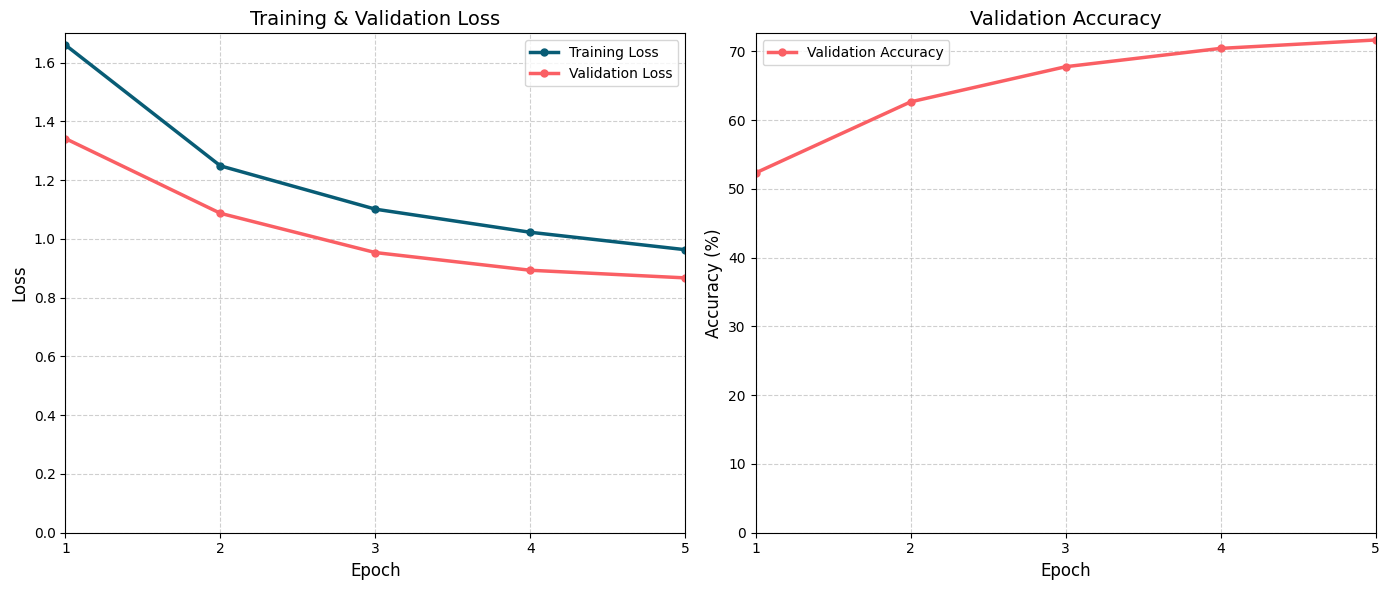

In [17]:
def plot_training_metrics(metrics):
    """
    Plots the training and validation metrics from a model training process.

    This function generates two side-by-side plots:
    1. Training Loss vs. Validation Loss.
    2. Validation Accuracy.

    Args:
        metrics (list): A list or tuple containing three lists:
                        [train_losses, val_losses, val_accuracies].
    """
    train_losses, val_losses, val_accuracies = metrics

    # Number of epochs from the length of the list
    num_epochs = len(train_losses)
    # Create a 1-indexed range of epoch numbers for the x-axis
    epochs = range(1, num_epochs + 1)

    # Create a figure and a set of subplots with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Configure the first subplot for training and validation loss ---
    # Select the first subplot
    ax1 = axes[0]
    # Plot training loss data
    ax1.plot(epochs, train_losses, color='#085c75', linewidth=2.5, marker='o', markersize=5, label='Training Loss')
    # Plot validation loss data
    ax1.plot(epochs, val_losses, color='#fa5f64', linewidth=2.5, marker='o', markersize=5, label='Validation Loss')
    ax1.set_title('Training & Validation Loss', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend()
    # Add a grid for better readability
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Configure the second subplot for validation accuracy ---
    # Select the second subplot
    ax2 = axes[1]
    # Plot validation accuracy data
    ax2.plot(epochs, val_accuracies, color='#fa5f64', linewidth=2.5, marker='o', markersize=5, label='Validation Accuracy')
    ax2.set_title('Validation Accuracy', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    # --- Apply dynamic and consistent styling to both subplots ---
    # Calculate a suitable interval for the x-axis ticks to avoid clutter
    x_interval = (num_epochs - 1) // 10 + 1

    # Loop through each subplot to apply common axis settings
    for ax in axes:
        # Set the y-axis to start at 0 and the x-axis to span the epochs
        ax.set_ylim(bottom=0)
        ax.set_xlim(left=1, right=num_epochs)

        # Set the major tick locator for the x-axis using the dynamic interval
        ax.xaxis.set_major_locator(mticker.MultipleLocator(x_interval))
        # Set the font size for the tick labels on both axes
        ax.tick_params(axis='both', which='major', labelsize=10)

    # Adjust subplot parameters for a tight layout
    plt.tight_layout()
    # Display the plots
    plt.show()


plot_training_metrics(training_metrics_proto)

#### Visualizing predictions

While the plots show your model's overall performance, looking at individual predictions provides a more intuitive feel for its strengths and weaknesses. You can now use a helper function to see your model in action, visualizing its predictions on random images from the validation set. This will show you concrete examples of where it succeeds and where it might be making mistakes.

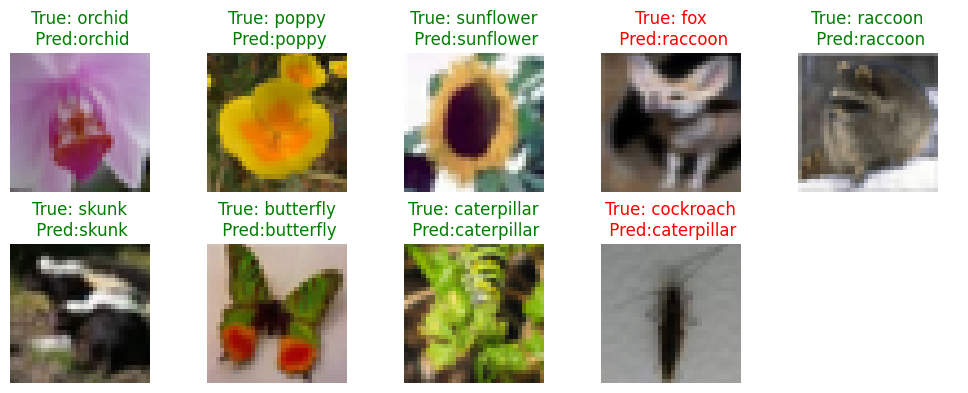

In [18]:
def visualize_predictions(model, data_loader, device, grid):
  """
    Visualizes model predictions on a grid of images from a dataset.

    Args:
        model: The trained PyTorch model to use for predictions.
        data_loader: The PyTorch DataLoader for the dataset.
        device: The device (e.g., 'cpu' or 'cuda') to run the model on.
        grid (tuple): A tuple specifying the number of rows and columns for the image grid.
    """
  model = model.to(device)
  model.eval()

  dataset = data_loader.dataset
  class_names = dataset.classes

  # Create a dict of indices for each class
  class_indices = defaultdict(list)
  for idx, target in enumerate(dataset.targets):
    class_indices[target].append(idx)

  rows, cols = grid
  n_images = rows * cols

  # Create figure
  fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
  # Iterate over each subplot
  for i, ax in enumerate(axes.flat):
    if i >= n_images:
      ax.axis("off")
      continue
    #if i >= len(class_names):
    #  i = i % len(class_names)
    #  print(i)

    # Set the class label based on the idx
    class_label = i
    # Get the list of image indices for the current class
    indices_for_class = class_indices[class_label]

    # If no images for class skip
    if not indices_for_class:
      ax.axis("off")
      continue

    # Retrieve a random image
    random_img = np.random.choice(indices_for_class)
    img_tensor, true_label = dataset[random_img]

    # Add a dimension (batch) so we can do inference
    image_batch = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
      # Make a prediction using our model
      output = model(image_batch)
      # Get the final predicted class
      _, pred_idx = torch.max(output, 1)

    # Extract the predicted label
    predicted_label = pred_idx.item()

    # Display Image
    denormalized_img = denormalize_image(img_tensor, cifar100_mean, cifar100_std)
    denormalized_img = denormalized_img.cpu().numpy().transpose((1,2,0))

    # Clip the pixel values to the valid range [0, 1]
    clipped_img = np.clip(denormalized_img, 0, 1)

    # Get the string names for the pred and true class
    true_name = class_names[true_label]
    pred_name = class_names[predicted_label]

    # Set appropriate title color
    title_color = 'green' if true_label == predicted_label else 'red'

    # Display image
    ax.imshow(clipped_img)
    ax.set_title(f"True: {true_name}\n Pred:{pred_name}", color=title_color)
    ax.axis("off")

  plt.tight_layout()
  plt.show()


visualize_predictions(trained_model_proto, val_loader_proto, device, (2,5))

## Scaling Up: Training the full model

We are going now to repeat the same steps as before, but this time using the full, more challenging dataset of 15 classes.

In [19]:
# Define the full class list.
all_target_classes = [
    # Flowers
    'orchid', 'poppy', 'rose', 'sunflower', 'tulip',
    # Mammals
    'fox', 'porcupine', 'possum', 'raccoon', 'skunk',
    # Insects
    'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'
]

# Load the dataset
train_dataset, val_dataset = load_cifar100_subset(all_target_classes, train_transform, test_transform)

Dataset already downloaded, skipping...
Dataset downloaded succesfully!


In [20]:
print(train_dataset)
print(val_dataset)

Dataset CIFAR100
    Number of datapoints: 7500
    Root location: /content/cifar_100/
    Split: Train
    StandardTransform
Transform: Compose(
               RandomHorizontalFlip(p=0.5)
               RandomVerticalFlip(p=0.2)
               RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
           )
Dataset CIFAR100
    Number of datapoints: 1500
    Root location: /content/cifar_100/
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
           )


In [21]:
# Now is the time to create the DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [22]:
# Get number of classes
n_classes = len(train_loader.dataset.classes)

# Instance of our CNN model
model_full = SimpleCNN(n_classes)
print(model_full)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (max_pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (max_pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (max_pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=15, bias=True)
)


In [23]:
# Define the optimizer
optimizer = optim.Adam(model_full.parameters(), lr=0.001)

In [24]:
# Training the model
trained_model, training_metrics = training_loop(
    model=model_full,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=15,
    device=device,
    profiling=False
)

Training started
Epoch 1/15: Training loss: 2.2388 
Test loss: 1.8353 
Test Accuracy: 36.53
Epoch 2/15: Training loss: 1.8532 
Test loss: 1.6450 
Test Accuracy: 43.93
Epoch 3/15: Training loss: 1.6972 
Test loss: 1.5527 
Test Accuracy: 48.07
Epoch 4/15: Training loss: 1.5816 
Test loss: 1.3899 
Test Accuracy: 53.07
Epoch 5/15: Training loss: 1.5023 
Test loss: 1.4223 
Test Accuracy: 51.80
Epoch 6/15: Training loss: 1.4523 
Test loss: 1.2905 
Test Accuracy: 56.67
Epoch 7/15: Training loss: 1.3677 
Test loss: 1.2370 
Test Accuracy: 60.33
Epoch 8/15: Training loss: 1.3055 
Test loss: 1.2176 
Test Accuracy: 59.13
Epoch 9/15: Training loss: 1.2564 
Test loss: 1.2552 
Test Accuracy: 59.73
Epoch 10/15: Training loss: 1.2251 
Test loss: 1.1739 
Test Accuracy: 60.87
Epoch 11/15: Training loss: 1.1752 
Test loss: 1.1169 
Test Accuracy: 64.07
Epoch 12/15: Training loss: 1.1238 
Test loss: 1.0982 
Test Accuracy: 62.27
Epoch 13/15: Training loss: 1.0884 
Test loss: 1.0737 
Test Accuracy: 64.33
Epoc

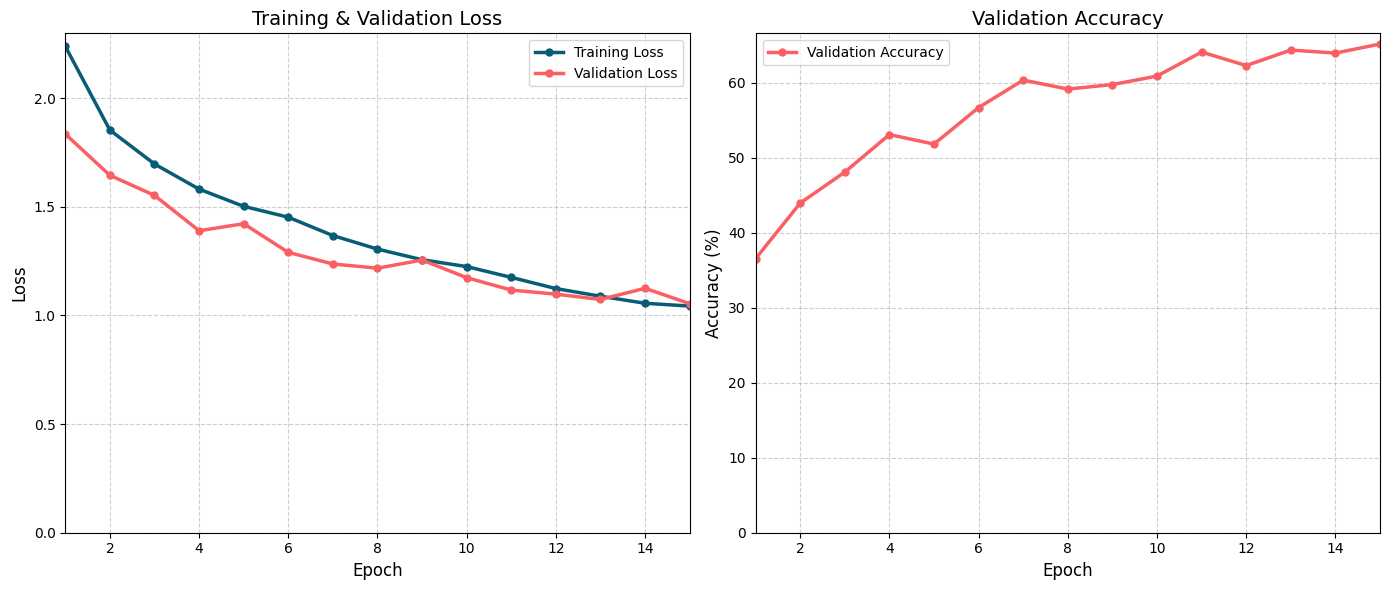

In [25]:
plot_training_metrics(training_metrics)

<br>

After training the full model, you can analyze the results. But wait, something isn't right here. Your prototype model trained successfully, showing steady improvement. However, the performance on the full 15-class dataset seems to have hit a wall. What happened?

A close look at the plots reveals the problem. While the **Training Loss** consistently decreases, the **Validation Loss** drops for a while and then begins to rise and fluctuate. At the same time, the **Validation Accuracy** gets stuck, plateauing without making further significant progress. This is a classic case of **overfitting**.

Overfitting occurs when a model learns the training data *too well*, including its noise and specific quirks, instead of the general, underlying patterns that would help it perform on new, unseen data. The widening gap between your training and validation loss is a clear sign your model is memorizing the training set instead of learning to **generalize**.

You might wonder why this happened now and not with the 9-class prototype. The reason is the significant increase in **task complexity**. Distinguishing between 15 classes is much harder than 9, requiring the model to learn more subtle features. Faced with this harder challenge, your powerful CNN model found an easier path to lowering the training loss: it started to memorize the training data instead of learning to generalize.

This overfitting problem presents a realistic challenge, similar to what you'd encounter in a real-world project. In this module's graded assignment, you'll tackle this issue by making several updates to your entire pipeline to see if you can improve the model's ability to generalize.

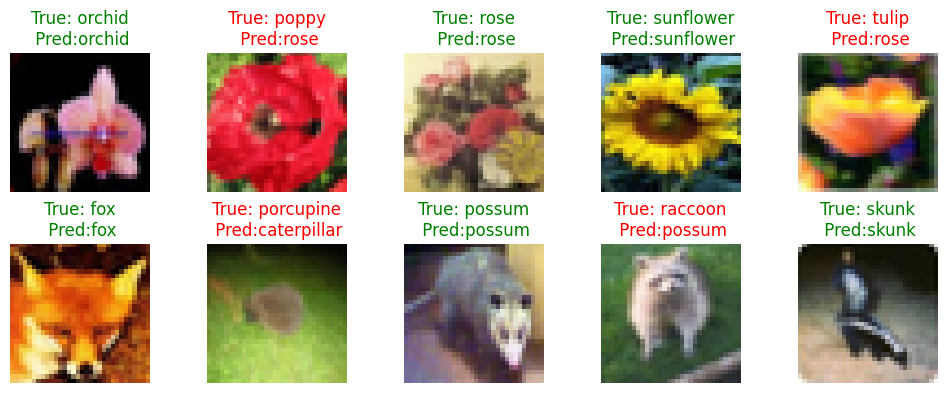

In [26]:
visualize_predictions(trained_model, val_loader, device, (2,5))